# MediaPipe Hand Landmarker — Video Reference Notebook

This notebook demonstrates how to use the MediaPipe Hand Landmarker Tasks API in **VIDEO mode** to extract 21 hand landmarks from each frame of a video.

This is the video counterpart of the [image reference notebook](mediapipe_reference.ipynb). We use the letter **J** video (`video-J.mp4`) as the test case — J is a dynamic sign that requires motion to distinguish, making it ideal for demonstrating frame-by-frame tracking.

**References:**
- [Hand Landmarker docs](https://ai.google.dev/edge/mediapipe/solutions/vision/hand_landmarker)
- [Python guide](https://ai.google.dev/edge/mediapipe/solutions/vision/hand_landmarker/python)
- [Running modes](https://ai.google.dev/edge/mediapipe/solutions/vision/hand_landmarker/python#running_mode)

## 1. Imports

In [1]:
import mediapipe as mp
import cv2
import numpy as np
import matplotlib.pyplot as plt
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

## 2. Setup the Hand Landmarker (VIDEO mode)

The key difference from image mode is `running_mode=vision.RunningMode.VIDEO`. In this mode:
- Frames must be fed **in chronological order** with increasing timestamps.
- MediaPipe uses temporal context for smoother, more consistent tracking.
- The `detect_for_video()` method is used instead of `detect()`.

Make sure you have the model file at `models/hand_landmarker.task`.

Download it with:
```bash
curl -o models/hand_landmarker.task https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/latest/hand_landmarker.task
```

In [2]:
MODEL_PATH = "../models/hand_landmarker.task"
VIDEO_PATH = "video-J.mp4"

base_options = python.BaseOptions(model_asset_path=MODEL_PATH)
options = vision.HandLandmarkerOptions(
    base_options=base_options,
    running_mode=vision.RunningMode.VIDEO,
    num_hands=1,
    min_hand_detection_confidence=0.5,
    min_hand_presence_confidence=0.5,
    min_tracking_confidence=0.5,
)

print("Hand Landmarker configured in VIDEO mode")

Hand Landmarker configured in VIDEO mode


## 3. Load and Inspect the Video

Video: video-J.mp4
Resolution: 576x1024
FPS: 30.0
Total frames: 95
Duration: 3.17s


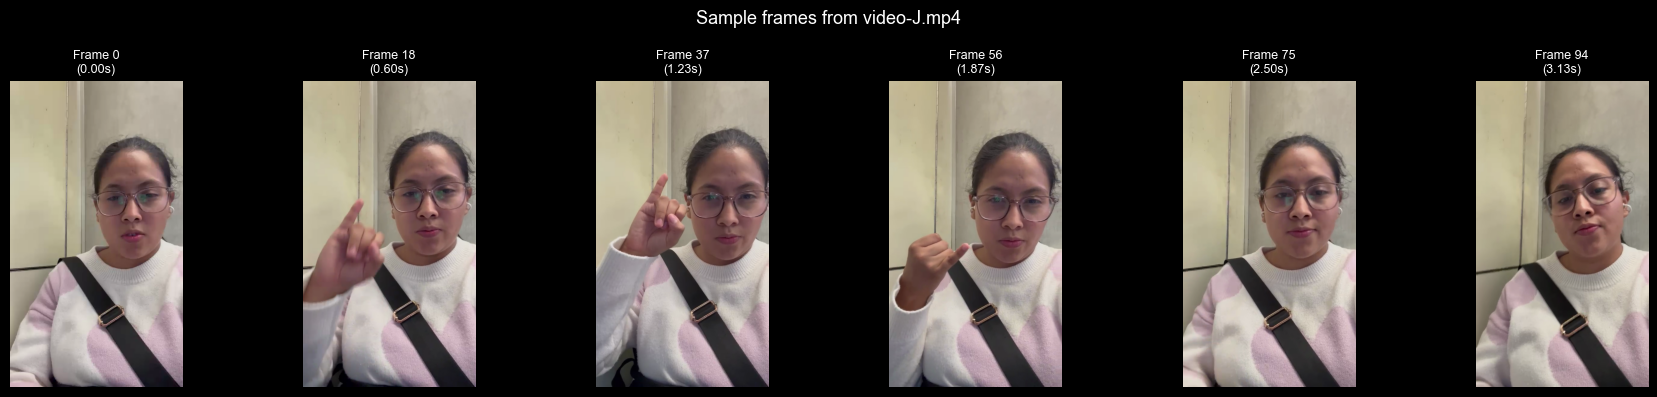

In [3]:
cap = cv2.VideoCapture(VIDEO_PATH)

fps = cap.get(cv2.CAP_PROP_FPS)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
duration = total_frames / fps

print(f"Video: {VIDEO_PATH}")
print(f"Resolution: {width}x{height}")
print(f"FPS: {fps}")
print(f"Total frames: {total_frames}")
print(f"Duration: {duration:.2f}s")

# Show a sample of frames evenly spaced across the video
sample_indices = np.linspace(0, total_frames - 1, 6, dtype=int)
fig, axes = plt.subplots(1, 6, figsize=(18, 4))

for ax, idx in zip(axes, sample_indices):
    cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
    ret, frame = cap.read()
    if ret:
        ax.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        ax.set_title(f"Frame {idx}\n({idx/fps:.2f}s)", fontsize=9)
    ax.axis("off")

plt.suptitle("Sample frames from video-J.mp4", fontsize=13)
plt.tight_layout()
plt.show()

cap.release()

## 4. Run Detection on All Frames

In VIDEO mode, we call `detect_for_video(mp_image, timestamp_ms)` for each frame. The timestamp must be **monotonically increasing** (in milliseconds).

In [4]:
cap = cv2.VideoCapture(VIDEO_PATH)
all_results = []   # (frame_idx, timestamp_ms, result)
all_frames = []    # BGR frames for visualization

with vision.HandLandmarker.create_from_options(options) as landmarker:
    frame_idx = 0
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        # Convert BGR → RGB and wrap in MediaPipe Image
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame_rgb)

        # Timestamp in milliseconds (derived from frame index and FPS)
        timestamp_ms = int(frame_idx * 1000 / fps)

        result = landmarker.detect_for_video(mp_image, timestamp_ms)

        all_results.append((frame_idx, timestamp_ms, result))
        all_frames.append(frame_rgb)
        frame_idx += 1

cap.release()

detected = sum(1 for _, _, r in all_results if r.hand_landmarks)
print(f"Processed {len(all_results)} frames")
print(f"Hand detected in {detected}/{len(all_results)} frames ({detected/len(all_results):.1%})")

I0000 00:00:1779766682.564779 41935328 init-domain.cc:128] Fiber init: default domain = pthread, concurrency = 15, prefix = pthread-default
I0000 00:00:1779766682.633449 41935328 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M4 Pro
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1779766682.642825 41935333 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1779766682.653845 41935336 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1779766682.668992 41935342 landmark_projection_calculator.cc:81] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.


Processed 95 frames
Hand detected in 60/95 frames (63.2%)


## 5. Inspect Landmarks for a Single Frame

In [5]:
LANDMARK_NAMES = [
    "WRIST",
    "THUMB_CMC", "THUMB_MCP", "THUMB_IP", "THUMB_TIP",
    "INDEX_MCP", "INDEX_PIP", "INDEX_DIP", "INDEX_TIP",
    "MIDDLE_MCP", "MIDDLE_PIP", "MIDDLE_DIP", "MIDDLE_TIP",
    "RING_MCP", "RING_PIP", "RING_DIP", "RING_TIP",
    "PINKY_MCP", "PINKY_PIP", "PINKY_DIP", "PINKY_TIP",
]

# Pick the middle frame that has a detection
mid = len(all_results) // 2
frame_idx, timestamp_ms, result = all_results[mid]

print(f"Frame {frame_idx} (t={timestamp_ms}ms)")

if result.hand_landmarks:
    print(f"Handedness: {result.handedness[0][0].display_name} "
          f"(confidence: {result.handedness[0][0].score:.4f})")
    print(f"\nLandmarks:")
    landmarks = result.hand_landmarks[0]
    for i, lm in enumerate(landmarks):
        print(f"[{i:2d}] {LANDMARK_NAMES[i]:15s} x={lm.x:.4f}  y={lm.y:.4f}  z={lm.z:.4f}")
else:
    print("No hand detected in this frame")

Frame 47 (t=1566ms)
Handedness: Right (confidence: 0.9951)

Landmarks:
[ 0] WRIST           x=0.0670  y=0.6126  z=-0.0000
[ 1] THUMB_CMC       x=0.1198  y=0.5683  z=0.0050
[ 2] THUMB_MCP       x=0.2129  y=0.5361  z=-0.0175
[ 3] THUMB_IP        x=0.3067  y=0.5391  z=-0.0417
[ 4] THUMB_TIP       x=0.3541  y=0.5585  z=-0.0611
[ 5] INDEX_MCP       x=0.2398  y=0.5023  z=-0.0670
[ 6] INDEX_PIP       x=0.3816  y=0.5329  z=-0.0941
[ 7] INDEX_DIP       x=0.3488  y=0.5599  z=-0.0966
[ 8] INDEX_TIP       x=0.3129  y=0.5594  z=-0.0975
[ 9] MIDDLE_MCP      x=0.2279  y=0.5328  z=-0.0880
[10] MIDDLE_PIP      x=0.3763  y=0.5674  z=-0.1091
[11] MIDDLE_DIP      x=0.3417  y=0.5915  z=-0.0966
[12] MIDDLE_TIP      x=0.3059  y=0.5902  z=-0.0899
[13] RING_MCP        x=0.2203  y=0.5703  z=-0.1058
[14] RING_PIP        x=0.3616  y=0.5972  z=-0.1139
[15] RING_DIP        x=0.3336  y=0.6132  z=-0.0860
[16] RING_TIP        x=0.2941  y=0.6104  z=-0.0701
[17] PINKY_MCP       x=0.2155  y=0.6087  z=-0.1239
[18] PINKY_P

## 6. Visualize Landmarks on Sample Frames

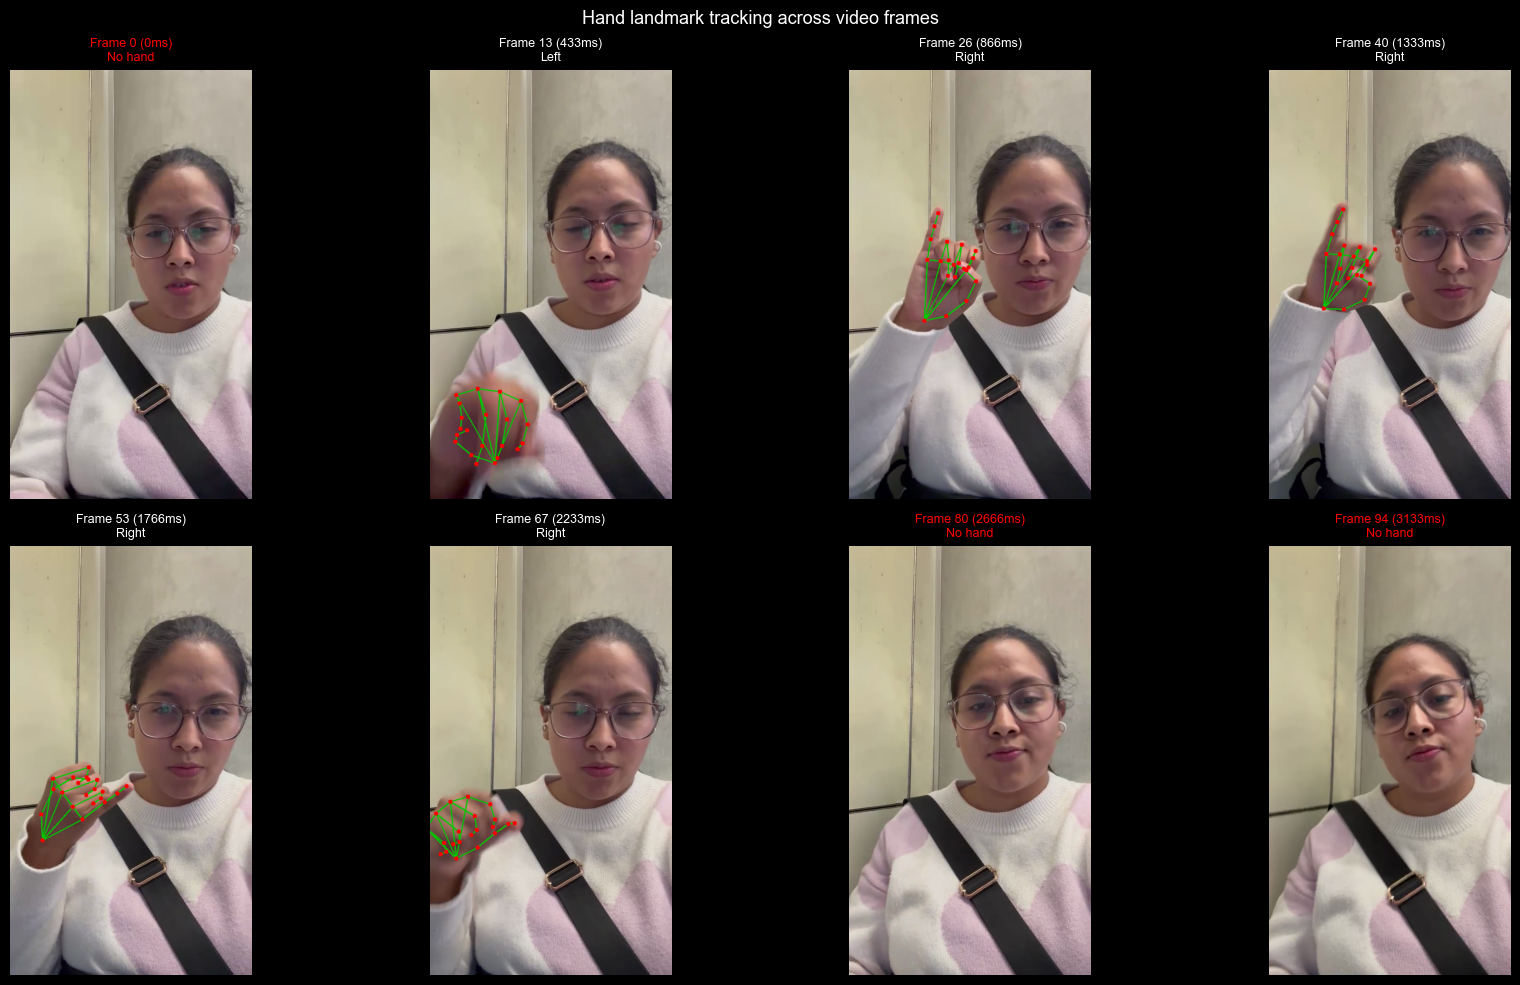

In [6]:
def draw_landmarks(image, detection_result):
    """Draw hand landmarks and connections on an image."""
    annotated = np.copy(image)
    h, w, _ = annotated.shape

    connections = [
        (0,1),(1,2),(2,3),(3,4),           # thumb
        (0,5),(5,6),(6,7),(7,8),           # index
        (0,9),(9,10),(10,11),(11,12),      # middle
        (0,13),(13,14),(14,15),(15,16),    # ring
        (0,17),(17,18),(18,19),(19,20),    # pinky
        (5,9),(9,13),(13,17),              # palm
    ]

    for hand_landmarks in detection_result.hand_landmarks:
        for start, end in connections:
            x0 = int(hand_landmarks[start].x * w)
            y0 = int(hand_landmarks[start].y * h)
            x1 = int(hand_landmarks[end].x * w)
            y1 = int(hand_landmarks[end].y * h)
            cv2.line(annotated, (x0, y0), (x1, y1), (0, 200, 0), 2)

        for lm in hand_landmarks:
            x = int(lm.x * w)
            y = int(lm.y * h)
            cv2.circle(annotated, (x, y), 5, (255, 0, 0), -1)

    return annotated


# Show 8 evenly spaced frames with landmarks overlaid
sample_indices = np.linspace(0, len(all_results) - 1, 8, dtype=int)
fig, axes = plt.subplots(2, 4, figsize=(18, 10))

for ax, idx in zip(axes.flat, sample_indices):
    frame_idx, ts, result = all_results[idx]
    frame = all_frames[idx]

    if result.hand_landmarks:
        annotated = draw_landmarks(frame, result)
        ax.imshow(annotated)
        handedness = result.handedness[0][0].display_name
        ax.set_title(f"Frame {frame_idx} ({ts}ms)\n{handedness}", fontsize=9)
    else:
        ax.imshow(frame)
        ax.set_title(f"Frame {frame_idx} ({ts}ms)\nNo hand", fontsize=9, color="red")
    ax.axis("off")

plt.suptitle("Hand landmark tracking across video frames", fontsize=13)
plt.tight_layout()
plt.show()

## 7. Extract Raw Keypoints (what goes into the model)

For video, we extract keypoints per frame, producing a **sequence** of shape `(n_frames, 21, 3)` — this is the input format needed for temporal models that classify dynamic signs like J and Z.

In [7]:
def extract_keypoints(detection_result):
    """Returns a list of 21 points: [[x,y,z], ...] or None if no hand detected."""
    if not detection_result.hand_landmarks:
        return None
    landmarks = detection_result.hand_landmarks[0]
    return [[lm.x, lm.y, lm.z] for lm in landmarks]


def extract_world_keypoints(detection_result):
    """Returns world-space landmarks: [[x,y,z], ...] or None."""
    if not detection_result.hand_world_landmarks:
        return None
    landmarks = detection_result.hand_world_landmarks[0]
    return [[lm.x, lm.y, lm.z] for lm in landmarks]


# Build per-frame keypoint sequence
keypoints_sequence = []
world_keypoints_sequence = []
timestamps = []

for frame_idx, ts, result in all_results:
    kp = extract_keypoints(result)
    wkp = extract_world_keypoints(result)
    if kp is not None:
        keypoints_sequence.append(kp)
        world_keypoints_sequence.append(wkp)
        timestamps.append(ts)

keypoints_array = np.array(keypoints_sequence)
world_keypoints_array = np.array(world_keypoints_sequence)

print(f"Keypoints sequence shape: {keypoints_array.shape}")
print(f"  → {keypoints_array.shape[0]} frames with detections")
print(f"  → {keypoints_array.shape[1]} landmarks per frame")
print(f"  → {keypoints_array.shape[2]} coordinates per landmark (x, y, z)")
print(f"\nWorld keypoints shape: {world_keypoints_array.shape}")
print(f"\nTimestamp range: {timestamps[0]}ms → {timestamps[-1]}ms")

Keypoints sequence shape: (60, 21, 3)
  → 60 frames with detections
  → 21 landmarks per frame
  → 3 coordinates per landmark (x, y, z)

World keypoints shape: (60, 21, 3)

Timestamp range: 400ms → 2366ms


## 8. Visualize Landmark Trajectories Over Time

Plotting how individual landmarks move across frames reveals the motion pattern of the sign. For letter J, we expect the pinky to trace a characteristic downward arc.

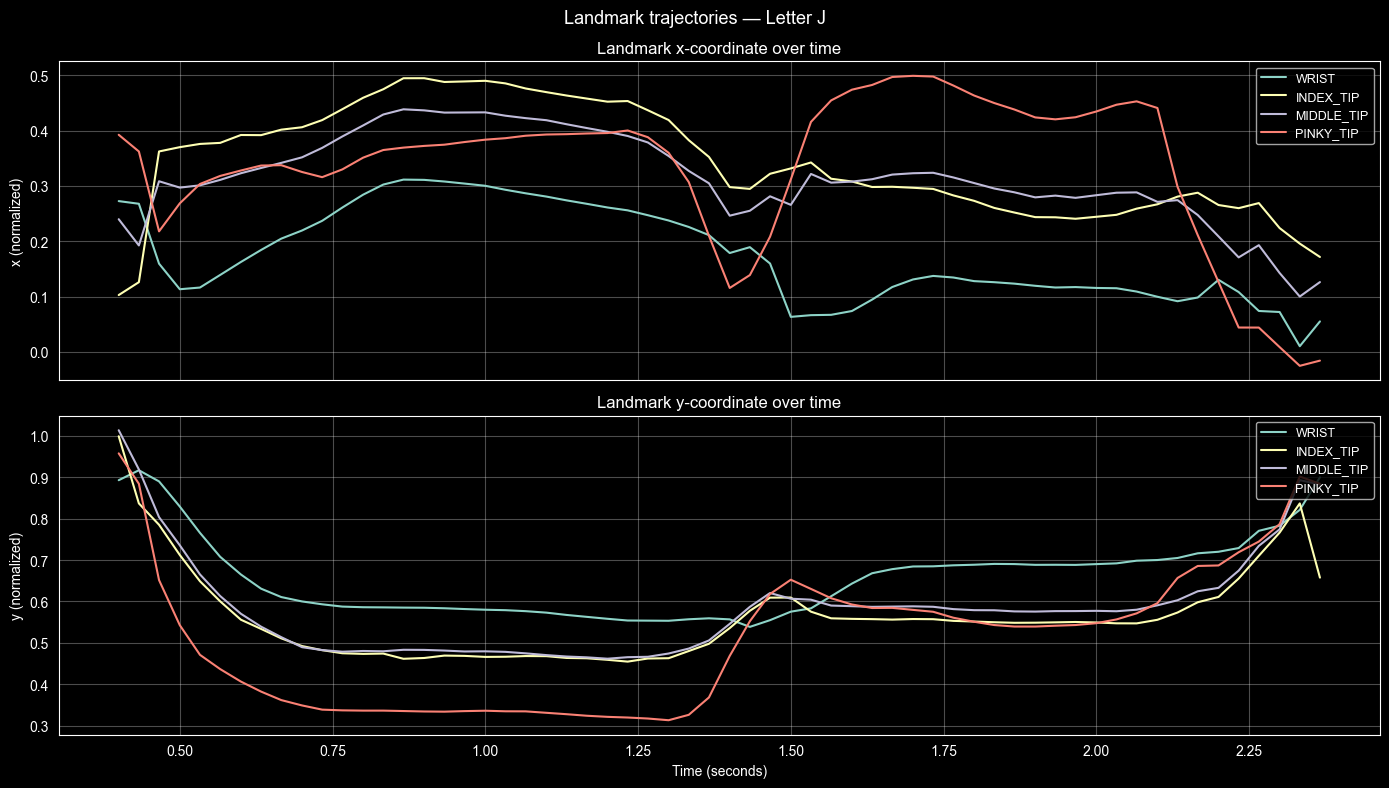

In [8]:
# Plot x, y trajectories over time for key landmarks
key_landmarks = {
    "WRIST": 0,
    "INDEX_TIP": 8,
    "MIDDLE_TIP": 12,
    "PINKY_TIP": 20,
}

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
time_sec = np.array(timestamps) / 1000

for name, idx in key_landmarks.items():
    axes[0].plot(time_sec, keypoints_array[:, idx, 0], label=name, linewidth=1.5)
    axes[1].plot(time_sec, keypoints_array[:, idx, 1], label=name, linewidth=1.5)

axes[0].set_ylabel("x (normalized)")
axes[0].set_title("Landmark x-coordinate over time")
axes[0].legend(loc="upper right", fontsize=9)
axes[0].grid(alpha=0.3)

axes[1].set_ylabel("y (normalized)")
axes[1].set_xlabel("Time (seconds)")
axes[1].set_title("Landmark y-coordinate over time")
axes[1].legend(loc="upper right", fontsize=9)
axes[1].grid(alpha=0.3)

plt.suptitle("Landmark trajectories — Letter J", fontsize=13)
plt.tight_layout()
plt.show()

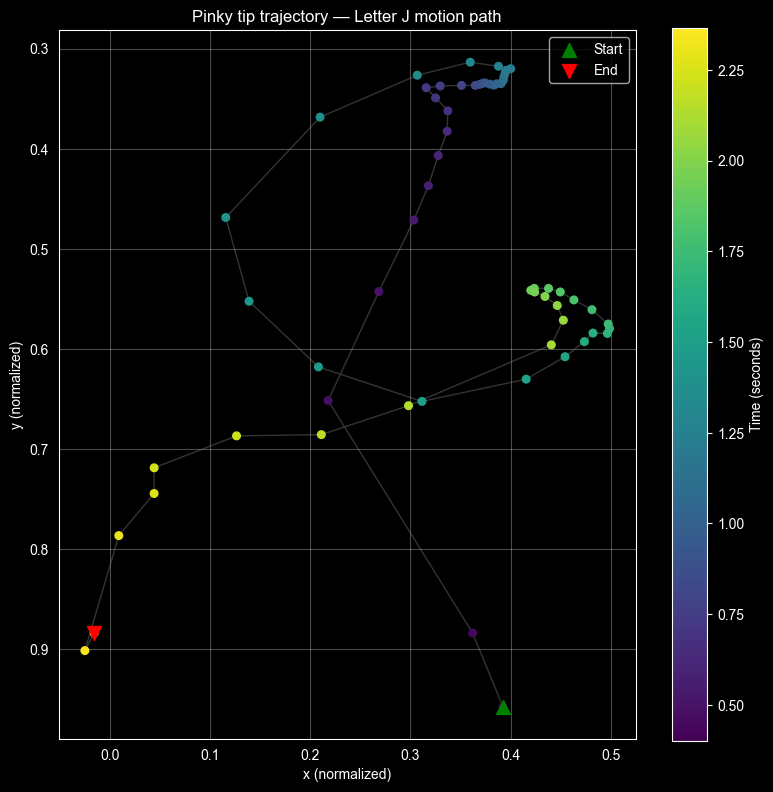

In [9]:
# 2D trajectory plot (x vs y) for the pinky tip — shows the motion path of the sign
fig, ax = plt.subplots(figsize=(8, 8))

pinky_x = keypoints_array[:, 20, 0]
pinky_y = keypoints_array[:, 20, 1]

# Color-code by time
scatter = ax.scatter(pinky_x, pinky_y, c=time_sec, cmap="viridis", s=30, zorder=3)
ax.plot(pinky_x, pinky_y, color="gray", alpha=0.4, linewidth=1, zorder=2)

# Mark start and end
ax.scatter(pinky_x[0], pinky_y[0], color="green", s=100, marker="^", zorder=4, label="Start")
ax.scatter(pinky_x[-1], pinky_y[-1], color="red", s=100, marker="v", zorder=4, label="End")

ax.set_xlabel("x (normalized)")
ax.set_ylabel("y (normalized)")
ax.set_title("Pinky tip trajectory — Letter J motion path")
ax.invert_yaxis()  # y=0 is top of image
ax.legend()
ax.grid(alpha=0.3)
ax.set_aspect("equal")

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Time (seconds)")

plt.tight_layout()
plt.show()

## 9. Export Keypoints as JSON

Same format as the image pipeline's `keypoints.json`, but with a `frame` and `timestamp_ms` field per entry. This makes it compatible with the existing data loading code.

In [10]:
import json

video_keypoints = []

for frame_idx, ts, result in all_results:
    if not result.hand_landmarks:
        continue

    entry = {
        "letter": "J",
        "file": VIDEO_PATH,
        "frame": frame_idx,
        "timestamp_ms": ts,
        "handedness": result.handedness[0][0].display_name,
        "handedness_confidence": result.handedness[0][0].score,
        "keypoints": [[lm.x, lm.y, lm.z] for lm in result.hand_landmarks[0]],
        "world_keypoints": [[lm.x, lm.y, lm.z] for lm in result.hand_world_landmarks[0]],
    }
    video_keypoints.append(entry)

print(f"Extracted {len(video_keypoints)} frame entries")
print(f"\nSample entry (frame {video_keypoints[0]['frame']}):")
sample = {k: v for k, v in video_keypoints[0].items() if k != "keypoints" and k != "world_keypoints"}
print(json.dumps(sample, indent=2))
print(f"  keypoints: [{len(video_keypoints[0]['keypoints'])} landmarks x 3 coords]")
print(f"  world_keypoints: [{len(video_keypoints[0]['world_keypoints'])} landmarks x 3 coords]")

Extracted 60 frame entries

Sample entry (frame 12):
{
  "letter": "J",
  "file": "video-J.mp4",
  "frame": 12,
  "timestamp_ms": 400,
  "handedness": "Left",
  "handedness_confidence": 0.9815457463264465
}
  keypoints: [21 landmarks x 3 coords]
  world_keypoints: [21 landmarks x 3 coords]
